# Seminar 6: A Couple of Fun Facts About Regressions and an Excursion into AN(C)OVA

In [1]:
import matplotlib.pyplot as plt
from matplotlib import offsetbox
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
sns.set(font_scale=1.5)
warnings.simplefilter("ignore")

In [2]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.api import interaction_plot, abline_plot
from statsmodels.stats.anova import anova_lm

# 1. OLS & Log-Reg vs. Omitting Variables

In this toy example, we will compare how omitting variables affects parameter estimates in an ordinary linear model and in logistic regression.

Our toy model has the following form:

$$y = \beta_1 x_1 + \beta_2 x_2 + \epsilon,\quad \epsilon \sim \mathcal{N}(0, 1)$$

## 1.1 Linear model

In [3]:
beta_1 = 1
beta_2 = 2.5

In [4]:
np.random.seed(1338)
N = 100000

x_1 = np.random.randn(N) * 10
x_2 = np.random.randn(N) * 10
noise = np.random.randn(N) / 5

y = x_1 * beta_1 + x_2 * beta_2 + noise

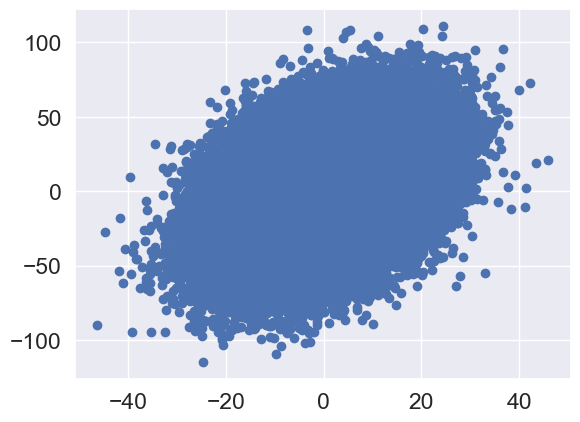

In [5]:
plt.scatter(x_1, y);

In [39]:
data = pd.DataFrame({'x_1': x_1, 'x_2': x_2, 'y': y})
fit = ols("y ~ x_1 -1", data).fit()
print(fit.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.139
Model:                            OLS   Adj. R-squared (uncentered):              0.139
Method:                 Least Squares   F-statistic:                          1.609e+04
Date:                Tue, 17 Feb 2026   Prob (F-statistic):                        0.00
Time:                        10:29:40   Log-Likelihood:                     -4.6365e+05
No. Observations:              100000   AIC:                                  9.273e+05
Df Residuals:                   99999   BIC:                                  9.273e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

# 1.2 Probit model

In [40]:
from scipy.stats import norm 
def probit(x):
    return norm.cdf(x)

data['y'] = probit(y)

In [41]:
fit = smf.glm('y ~ x_1 -1', 
              data=data, 
              family=sm.families.Binomial(sm.families.links.probit())).fit()

print(fit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:               100000
Model:                            GLM   Df Residuals:                    99999
Model Family:                Binomial   Df Model:                            0
Link Function:                 probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -63919.
Date:                Tue, 17 Feb 2026   Deviance:                   1.2416e+05
Time:                        10:29:40   Pearson chi2:                 9.63e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08773
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x_1            0.0401      0.000     92.804      0.0

### “Attenuation” Bias

https://stats.stackexchange.com/questions/113766/omitted-variable-bias-in-logistic-regression-vs-omitted-variable-bias-in-ordina/113832#113832

http://esr.oxfordjournals.org/content/26/1/67.full.pdf?keytype=ref&ijkey=R3RzO51agvA7eKQ

#### tl;dr if we omit a feature from the data, the coefficients of the remaining variables are shrunk toward zero

$$\hat\beta_1 \rightarrow \frac{\beta_1}{\sqrt{1 + \beta_2^2 \sigma^2_{x_2}}}$$

In [42]:
beta_1 / np.sqrt(1 + beta_2**2 * 100)

np.float64(0.039968038348871575)

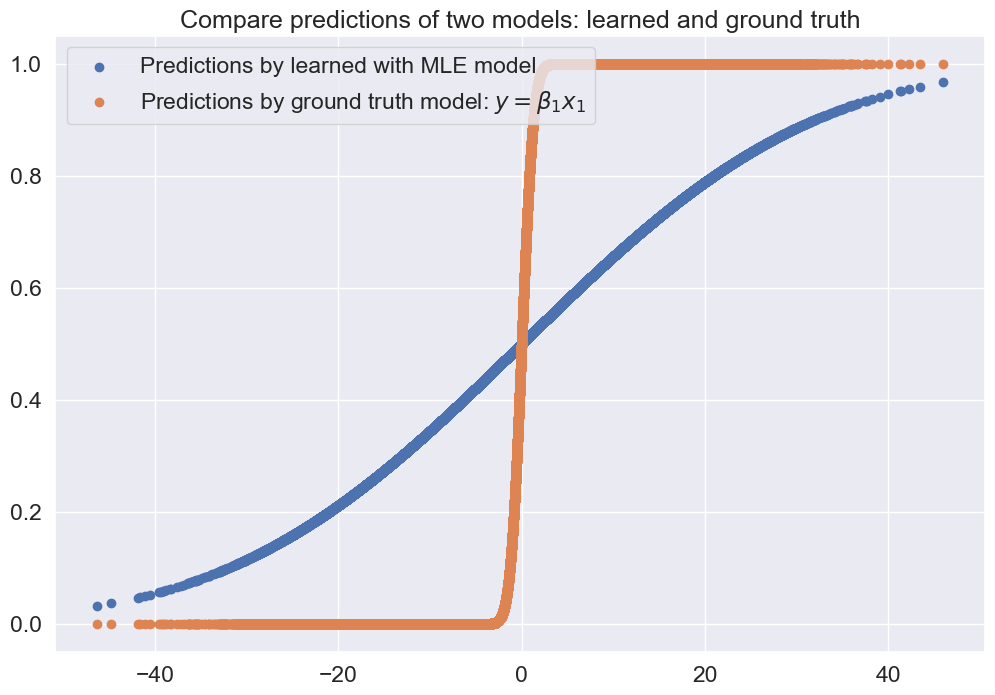

In [43]:
plt.figure(figsize=(12, 8))
plt.title("Compare predictions of two models: learned and ground truth")
plt.scatter(data['x_1'], fit.predict(data['x_1']).values, label="Predictions by learned with MLE model");
plt.scatter(data['x_1'], probit(x_1 * beta_1), label=r"Predictions by ground truth model: $y = \beta_1 x_1$");
plt.legend()
plt.show()

# 2. Measurement Error

Let us consider the following thought experiment: we take a linear model and add noise to the measured variable $x_1$:

$$y = \beta_1 x_1 + \beta_2 x_2$$

At the same time, in reality we observe a noisy version of this variable:

$$\hat x_1 = x_1 + \epsilon,\quad \epsilon \sim \mathcal{N}(0, 1)$$

In [6]:
np.random.seed(1338)
N = 10000
x_1 = np.random.randn(N)
x_2 = np.random.randn(N)

y = x_1 * beta_1 + x_2 * beta_2

x_1_noise = x_1 + np.random.randn(N)

In [7]:
data = pd.DataFrame(
    {
        'x_1': x_1_noise, 
        'x_2': x_2, 
        'y': y
    }
)
fit = ols("y ~ x_1 + x_2 -1", data).fit()
print(fit.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.930
Model:                            OLS   Adj. R-squared (uncentered):              0.930
Method:                 Least Squares   F-statistic:                          6.609e+04
Date:                Tue, 17 Feb 2026   Prob (F-statistic):                        0.00
Time:                        13:22:22   Log-Likelihood:                         -10727.
No. Observations:               10000   AIC:                                  2.146e+04
Df Residuals:                    9998   BIC:                                  2.147e+04
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------


This is called measurement error.

http://econ.lse.ac.uk/staff/spischke/ec524/Merr_new.pdf

$$\hat\beta_1 = \beta_1 \cdot \frac{\sigma_{x_1}^2}{\sigma_{x_1}^2 + \sigma_{\epsilon}^2}$$

Equivalently, the asymptotic bias is

$$\hat\beta_1 - \beta_1 = - \beta_1 \cdot \frac{\sigma_{\epsilon}^2}{\sigma_{x_1}^2 + \sigma_{\epsilon}^2}$$

## What to do?

1. If you know $ \sigma_{x_1} $ and $ \sigma_{\epsilon} $, then everything is great.

2. Suppose you do not know them, but you can measure some variable $ z $ that is correlated with $ x_1 $ but independent of $ \epsilon $. In that case, an unbiased estimate can be obtained as follows:

$$
\beta_{1} = \frac{\mathrm{Cov}(z, y)}{\mathrm{Cov}(z, x)}
$$

In [46]:
z = 5 * np.tanh(x_1) + np.random.randn(N) 

In [47]:
np.cov(z, y)[1, 0] / np.cov(z, x_1_noise)[1, 0]

np.float64(0.9553194111743988)

# 2. ANOVA

## Data for Experiments

![](cylinders.jpeg)

We will look at MPG data (= Miles Per Gallon) and explore various dependencies in the dataset.

The variables we will work with (https://archive.ics.uci.edu/ml/datasets/auto+mpg):

1. mpg: continuous
2. cylinders: multi-valued discrete
3. displacement: continuous
4. horsepower: continuous
5. weight: continuous
6. acceleration: continuous
7. model year: multi-valued discrete
8. origin: multi-valued discrete
9. car name: string (unique for each instance)

In [8]:
auto_mpg = pd.read_csv('./auto_mpg.data',sep='\s+',names = ['MPG','Cylinders','Displacement',
                                                        'Horse_power','Weight','Acceleration',
                                                        'Model_Year','Origin','Car_Name'])
auto_mpg = auto_mpg[auto_mpg.Horse_power.apply(lambda x: not '?' in x)]
auto_mpg.Horse_power = auto_mpg.Horse_power.apply(lambda x: float(x))
auto_mpg.reset_index(drop=True, inplace=True)

In [9]:
auto_mpg.MPG = np.log(1 / auto_mpg.MPG)

In [10]:
auto_mpg.head()

,MPG,Cylinders,Displacement,Horse_power,Weight,Acceleration,Model_Year,Origin,Car_Name
0,-2.890372,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,-2.708050,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,-2.890372,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,-2.772589,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,-2.833213,8,302.0,140.0,3449.0,10.5,70,1,ford torino


##### Let’s look at the distribution of MPG by horsepower

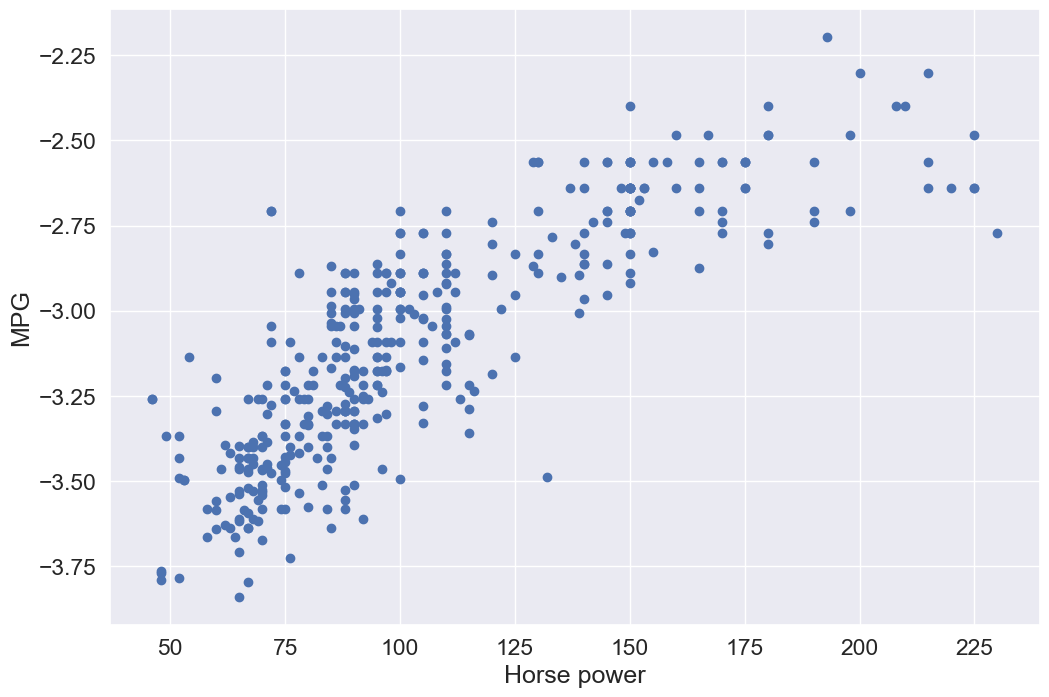

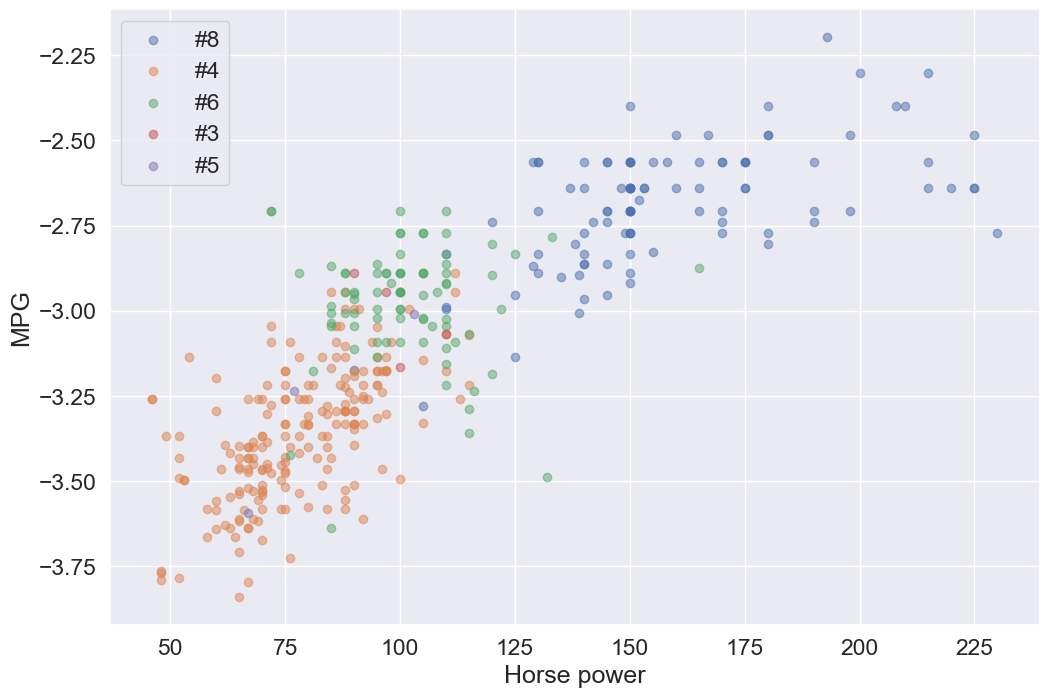

In [11]:
plt.figure(figsize=(12, 8))
plt.scatter(auto_mpg['Horse_power'], auto_mpg['MPG'])
plt.xlabel('Horse power')
plt.ylabel('MPG')
plt.show()

plt.figure(figsize=(12, 8))
for cylinder in auto_mpg.Cylinders.unique():
    plt.scatter(auto_mpg['Horse_power'][auto_mpg.Cylinders==cylinder], 
                auto_mpg['MPG'][auto_mpg.Cylinders==cylinder], alpha=0.5, 
                label='#{}'.format(cylinder))
plt.xlabel('Horse power')
plt.ylabel('MPG')
plt.legend()
plt.show()

### Let’s look at the distribution of MPG by engine weight

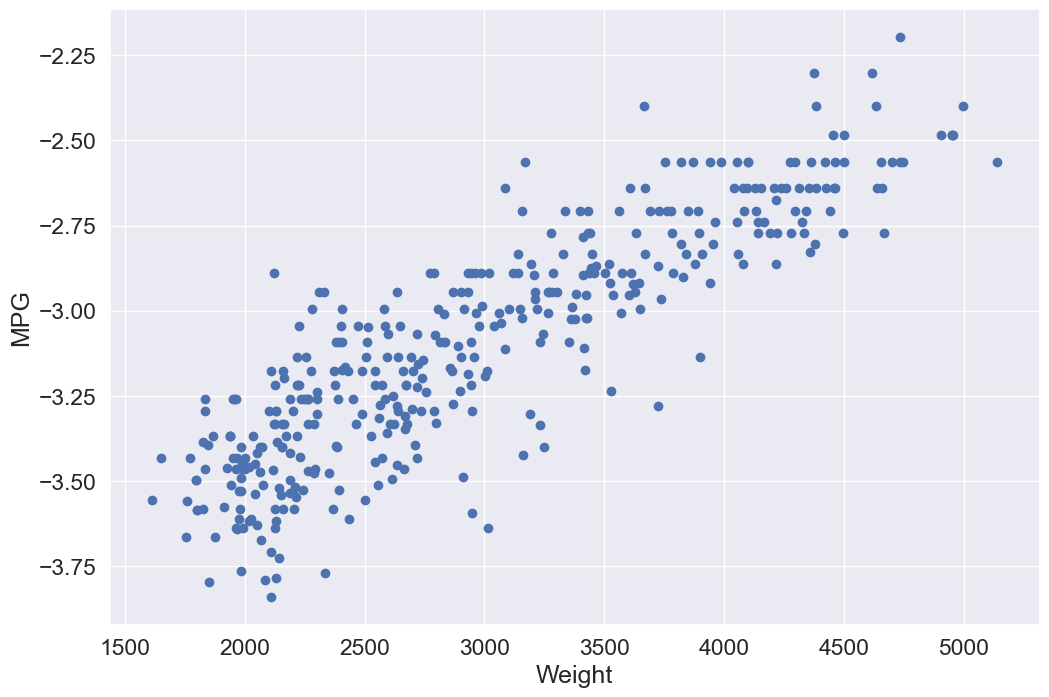

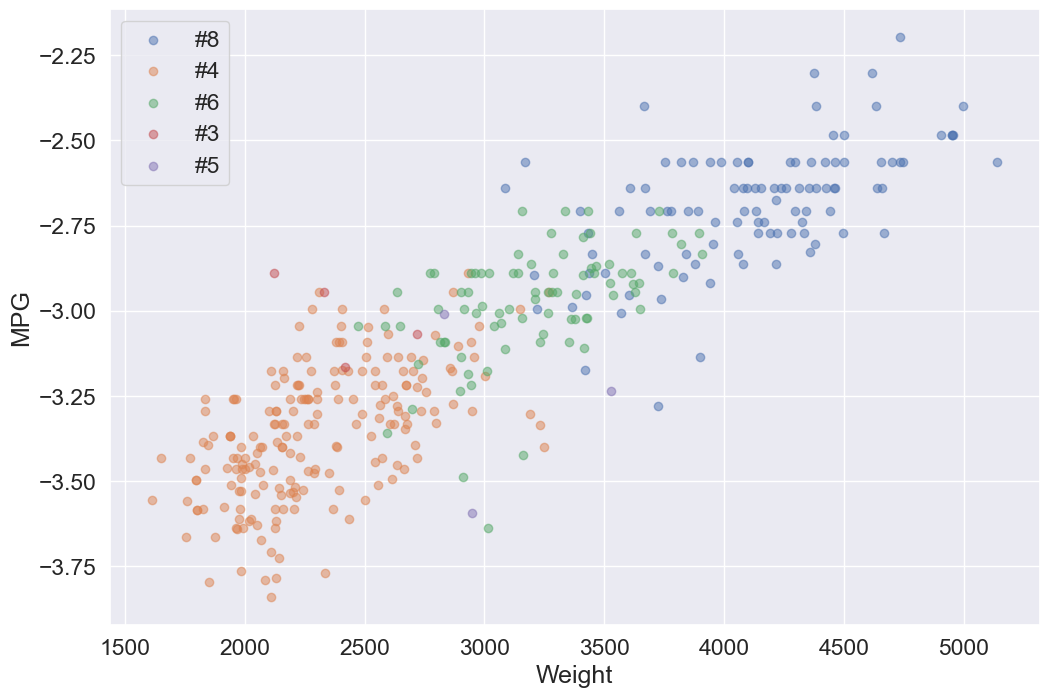

In [12]:
plt.figure(figsize=(12, 8))
plt.scatter(auto_mpg['Weight'], auto_mpg['MPG'])
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()

plt.figure(figsize=(12, 8))
for cylinder in auto_mpg.Cylinders.unique():
    plt.scatter(auto_mpg['Weight'][auto_mpg.Cylinders==cylinder], 
                auto_mpg['MPG'][auto_mpg.Cylinders==cylinder], 
                alpha=0.5, label='#{}'.format(cylinder))
plt.ylabel('MPG')
plt.xlabel('Weight')
plt.legend()
plt.show()

### Let’s look at the distribution of MPG by the number of cylinders

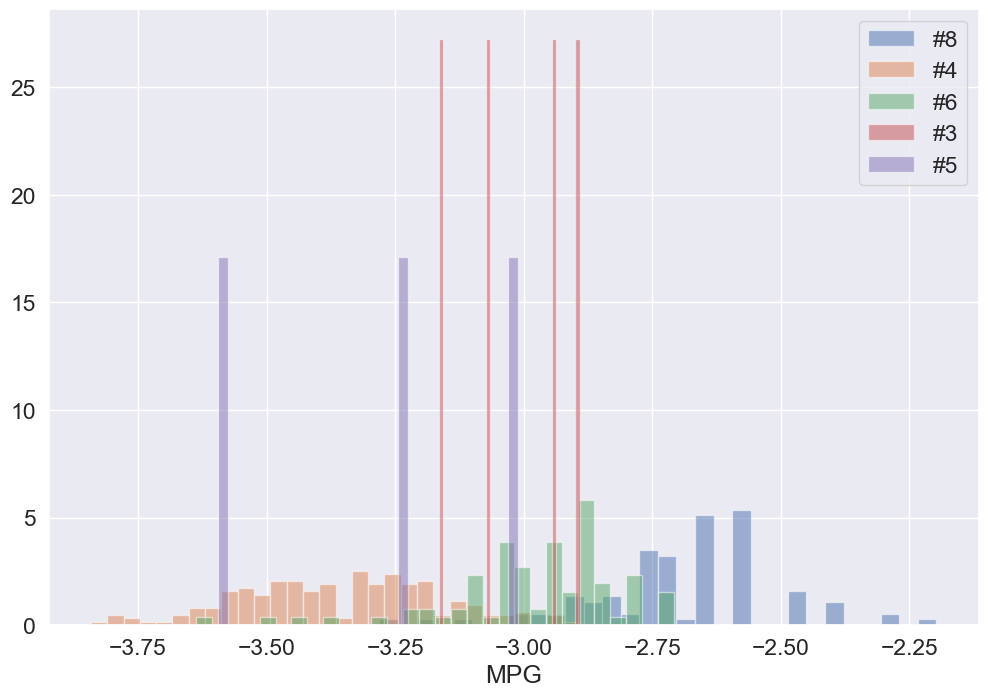

<Figure size 640x480 with 0 Axes>

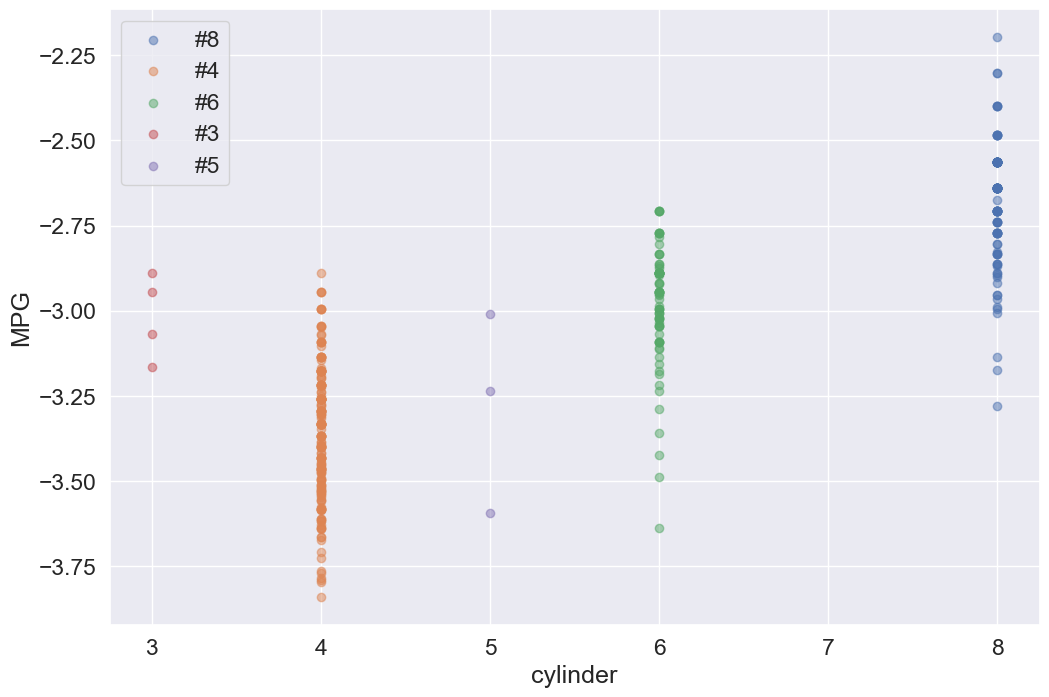

In [13]:
plt.figure(figsize=(12, 8))
for cylinder in auto_mpg.Cylinders.unique():
    plt.hist(auto_mpg['MPG'][auto_mpg.Cylinders==cylinder], 
             bins=30, alpha=0.5, label='#{}'.format(cylinder), density=True)
plt.legend()
plt.xlabel('MPG')
plt.show()

fig = plt.figure()
plt.figure(figsize=(12, 8))
for cylinder in auto_mpg.Cylinders.unique():
    plt.scatter([cylinder] * len(auto_mpg['MPG'][auto_mpg.Cylinders==cylinder]), 
                auto_mpg['MPG'][auto_mpg.Cylinders==cylinder], alpha=0.5, 
            label='#{}'.format(cylinder))
plt.legend()
plt.ylabel('MPG')
plt.xlabel('cylinder')
plt.show()

##### Let’s look at the distribution of MPG by country of origin

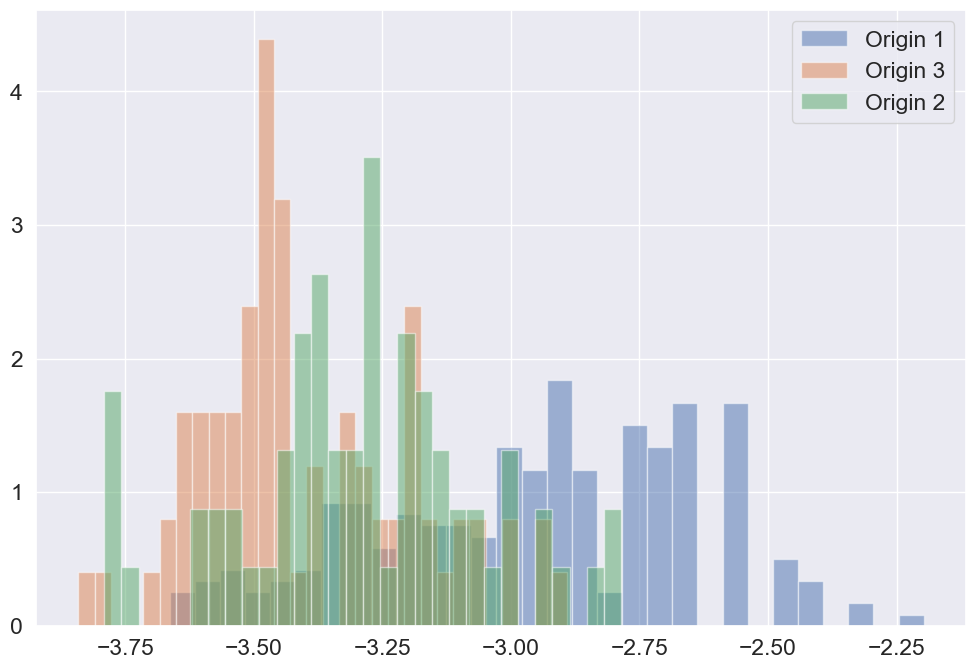

<Figure size 640x480 with 0 Axes>

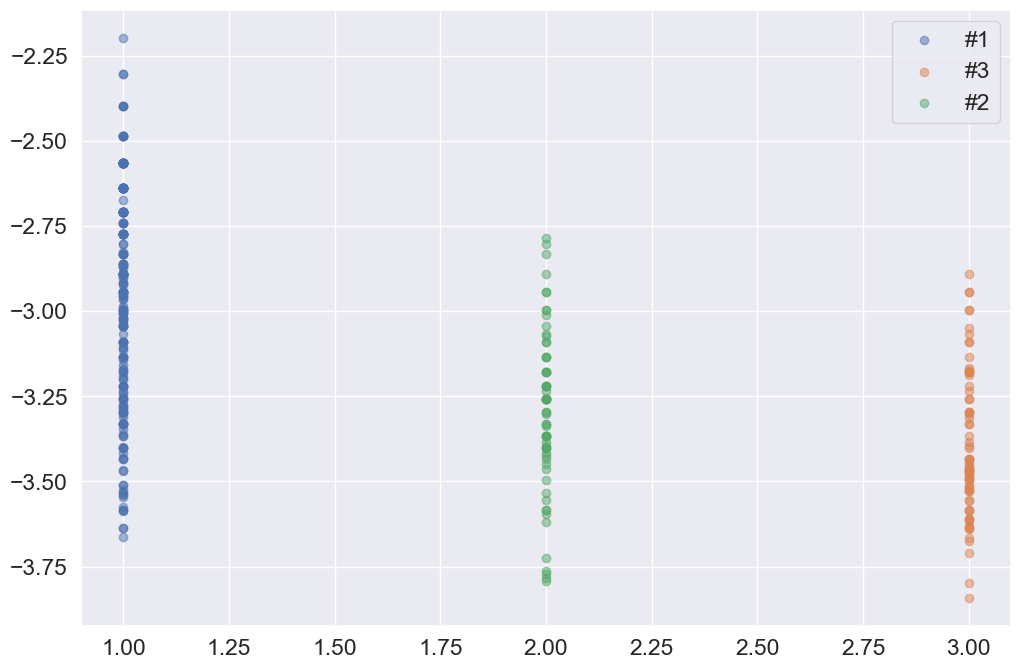

In [14]:
plt.figure(figsize=(12, 8))
for origin in auto_mpg.Origin.unique():
    plt.hist(auto_mpg['MPG'][auto_mpg.Origin==origin], 
             bins=30, alpha=0.5, label='Origin {}'.format(origin), density=True)
plt.legend()
plt.show()

fig = plt.figure()
plt.figure(figsize=(12, 8))
for origin in auto_mpg.Origin.unique():
    plt.scatter([origin] * len(auto_mpg['MPG'][auto_mpg.Origin==origin]), 
                auto_mpg['MPG'][auto_mpg.Origin==origin], alpha=0.5, 
                label='#{}'.format(origin))
plt.legend()
plt.show()

## F-test & ANOVA

The F-distribution (Fisher distribution):

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/a55e68498f7fd2c02998e8692ce340c3e9a5cedf)

It is parameterized by two quantities: $d_1$ and $d_2$, which are called degrees of freedom.

Why “degrees of freedom”? Because the Fisher distribution can be written as the ratio of two chi-squared variables:

$$
F = \frac{\chi^2(d_1) / d_1}{\chi^2(d_2) / d_2}
$$

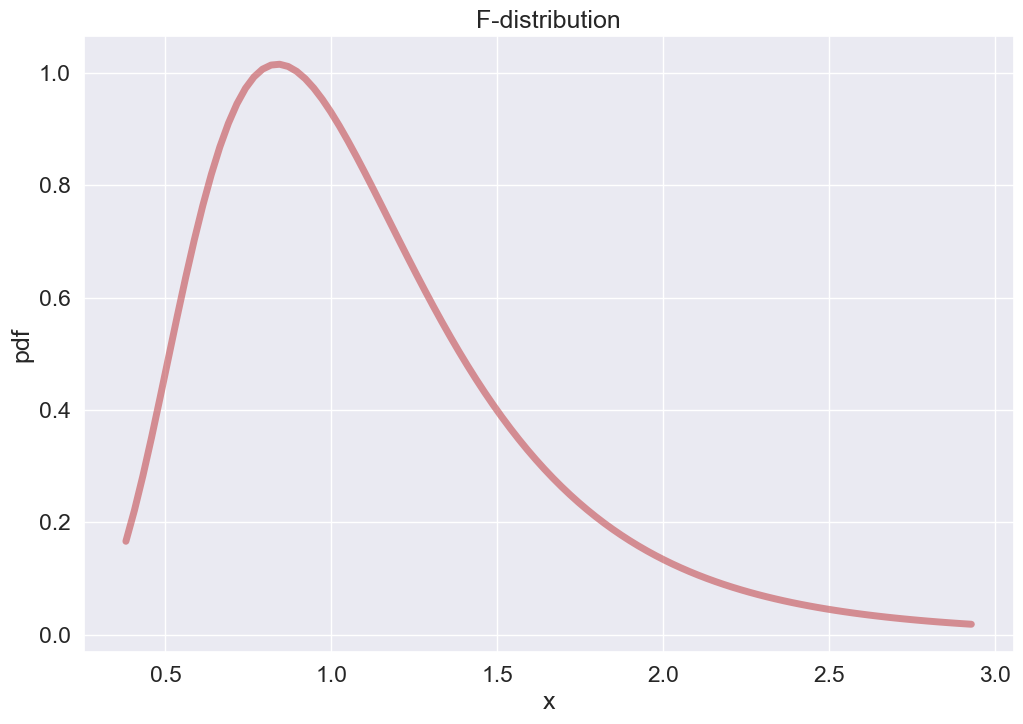

In [55]:
from scipy.stats import f
dfn, dfd = 29, 18

x = np.linspace(f.ppf(0.01, dfn, dfd),
                f.ppf(0.99, dfn, dfd), 100)

plt.figure(figsize=(12, 8))

plt.plot(x, f.pdf(x, dfn, dfd), 'r-', lw=5, alpha=0.6, label='f pdf')
plt.title('F-distribution')

plt.xlabel('x')
plt.ylabel('pdf')

plt.show()

## The Most Important ANOVA Table

#### What hypothesis are we testing?

$$\mathbb{H}_0:~~\textrm{all means are equal}$$  $$~~\mathrm{vs}~~$$  $$\mathbb{H}_1: ~~ \textrm{not all means are equal}$$


#### To do this, we first construct the variance table

| Type of Variation | SS  | df      | MS                         | F           |
|------------------|-----|---------|-----------------------------|-------------|
| Between groups   | SSG | k − 1   | MSG = SSG / (k − 1)         | MSG / MSE   |
| Within groups    | SSE | n − k   | MSE = SSE / (n − k)         |             |
| Total            | SST | n − 1   |                             |             |

What is the meaning of each type of variation?

* **Between groups (MSG):** variation between group means and the global mean  
* **Within groups (MSE):** variation between individual observations and their group means  
* **Total:** variation between observations and the global mean

#### After this, we compute the F‑statistic:

$$
F = \frac{MSG}{MSE}
$$

Previously we wrote:

$$
s^2 = \frac{1}{n - 1} \sum (x_i - \bar{x})^2
$$

$$
(n - 1)\,\frac{s^2}{\sigma^2} \sim \chi^2_{n - 1}
$$

Using this formula, one can explicitly derive that $MSG / MSE$ follows an $F$‑distribution.

#### And after that we can test the hypothesis:

If the null hypothesis is true, then the $F$‑statistic should follow an $F$‑distribution with degrees of freedom $k - 1$ and $n - k$.

If $P(F_{k-1, n - k} > F) < \alpha$, then $H_0$ is rejected.

## ANOVA в `statsmodels`

In [15]:
from statsmodels.formula.api import ols
from statsmodels.graphics.api import interaction_plot, abline_plot
from statsmodels.stats.anova import anova_lm

Let’s fit a linear model for the dependence of MPG on the number of cylinders:

In [57]:
formula = 'MPG ~ C(Cylinders)'
lm = ols(formula, auto_mpg).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     235.6
Date:                Tue, 17 Feb 2026   Prob (F-statistic):          2.71e-102
Time:                        10:29:55   Log-Likelihood:                 109.01
No. Observations:                 392   AIC:                            -208.0
Df Residuals:                     387   BIC:                            -188.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -3.0171      0.09

##### How the linear model sees the data

In [58]:
lm.model.data.orig_exog[:5]

,Intercept,C(Cylinders)[T.4],C(Cylinders)[T.5],C(Cylinders)[T.6],C(Cylinders)[T.8]
0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0


In [59]:
infl = lm.get_influence()
summary_table = infl.summary_table()

Now let’s plot the residuals.

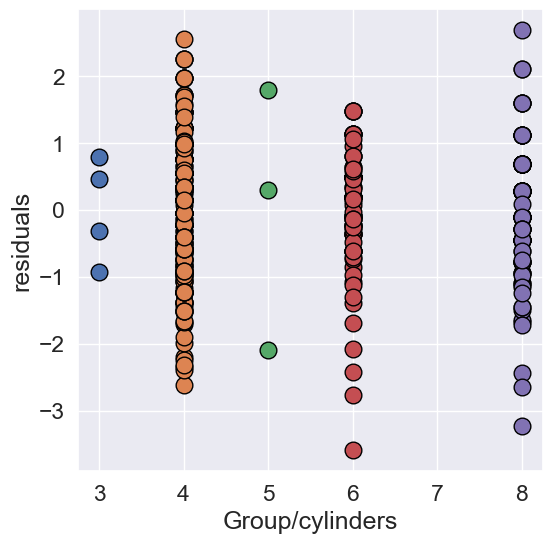

In [60]:
resid = infl.resid_studentized_internal
plt.figure(figsize=(6,6));
symbols = ['D', '^']
colors = ['r', 'g', 'blue']
for value, group in auto_mpg.groupby(['Cylinders']):
    x = [value] * len(group)
    plt.scatter(x, resid[group.index],
            s=144, edgecolors='black')
plt.xlabel('Group/cylinders');
plt.ylabel('residuals');

In [61]:
len(auto_mpg) - 5

387

In [62]:
anova_table = anova_lm(lm)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
C(Cylinders),4.0,32.049300,8.012325,235.608959,2.709276e-102
Residual,387.0,13.160661,0.034007,NaN,NaN


##### Let’s plot the residuals as a function of engine weight

It looks like there might be a slight trend…

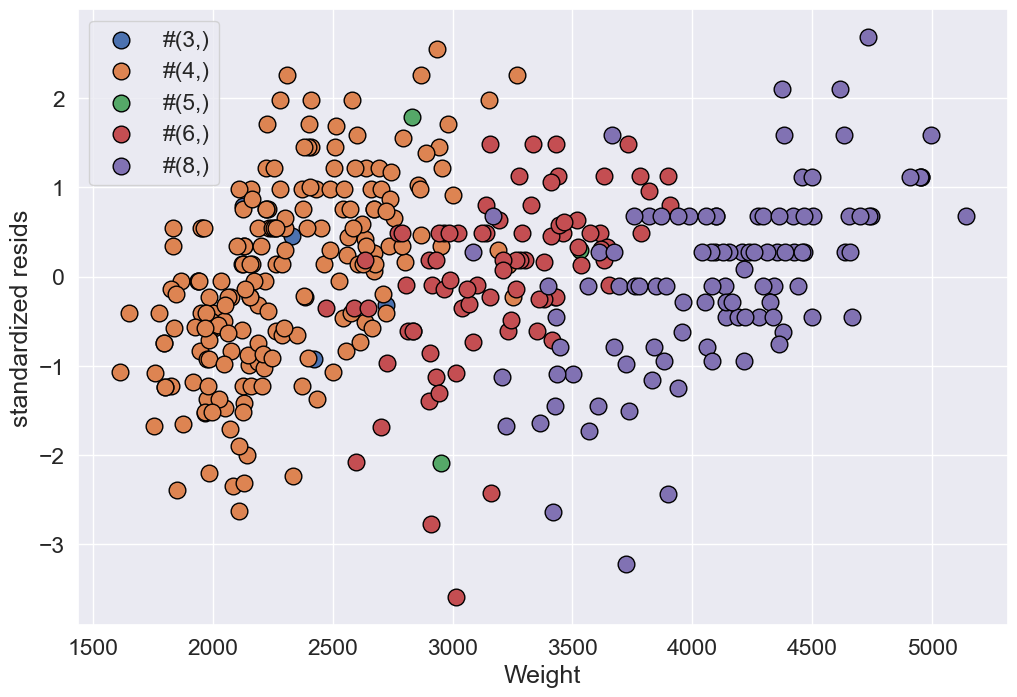

In [63]:
infl = lm.get_influence()
resid = infl.resid_studentized_internal
plt.figure(figsize=(12, 8))
for cylinder, group in auto_mpg.groupby(['Cylinders']):
    plt.scatter(auto_mpg.Weight[group.index], resid[group.index], s=144, 
                edgecolors='black', label='#{}'.format(cylinder))
plt.xlabel('Weight');
plt.ylabel('standardized resids');
plt.legend();

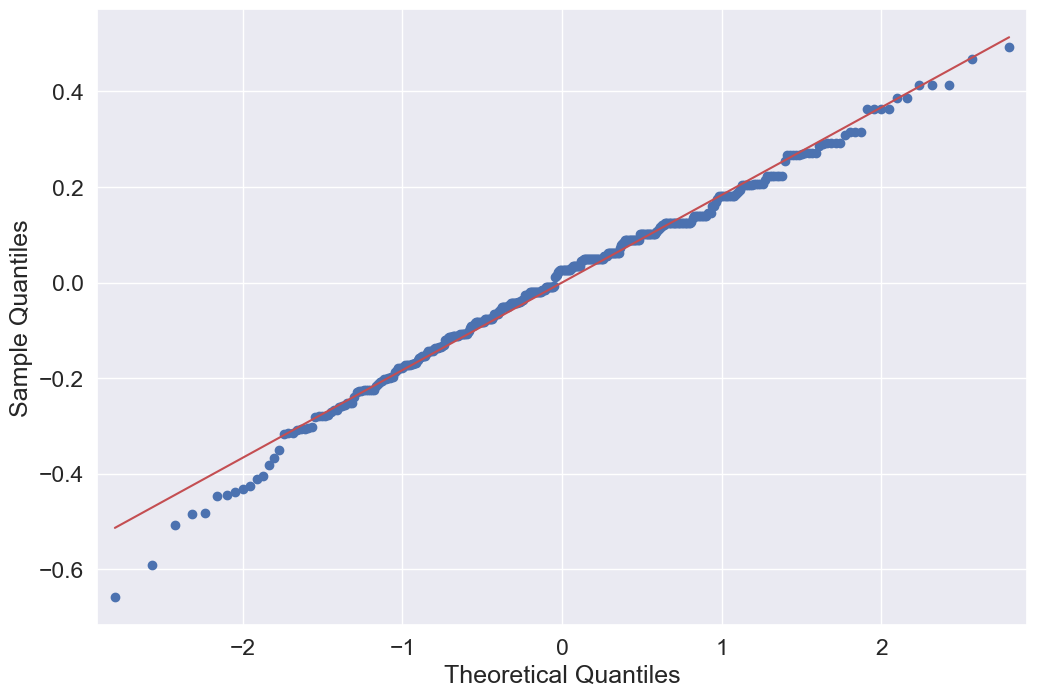

In [64]:
res = infl.resid 
fig = sm.qqplot(res, line='s')
fig.set_figheight(8)
fig.set_figwidth(12)
plt.show()

## 3 Two-way ANOVA

Let’s study the effect of vitamin C on tooth growth in guinea pigs ;)

![](https://homkin.ru/wp-content/uploads/2018/07/23-1-e1530703517235.jpg)

We have three variables:

1. `len` — tooth length  
2. `supp` — VC (ascorbic acid) / OJ (orange juice)  
3. `dose` — dose


In [4]:
datafile = "ToothGrowth.csv"
data = pd.read_csv(datafile)
data = data.reset_index()

In [5]:
data.head()

,index,Unnamed: 0,len,supp,dose
0,0,1,4.2,VC,0.5
1,1,2,11.5,VC,0.5
2,2,3,7.3,VC,0.5
3,3,4,5.8,VC,0.5
4,4,5,6.4,VC,0.5


Let’s build an interaction plot.

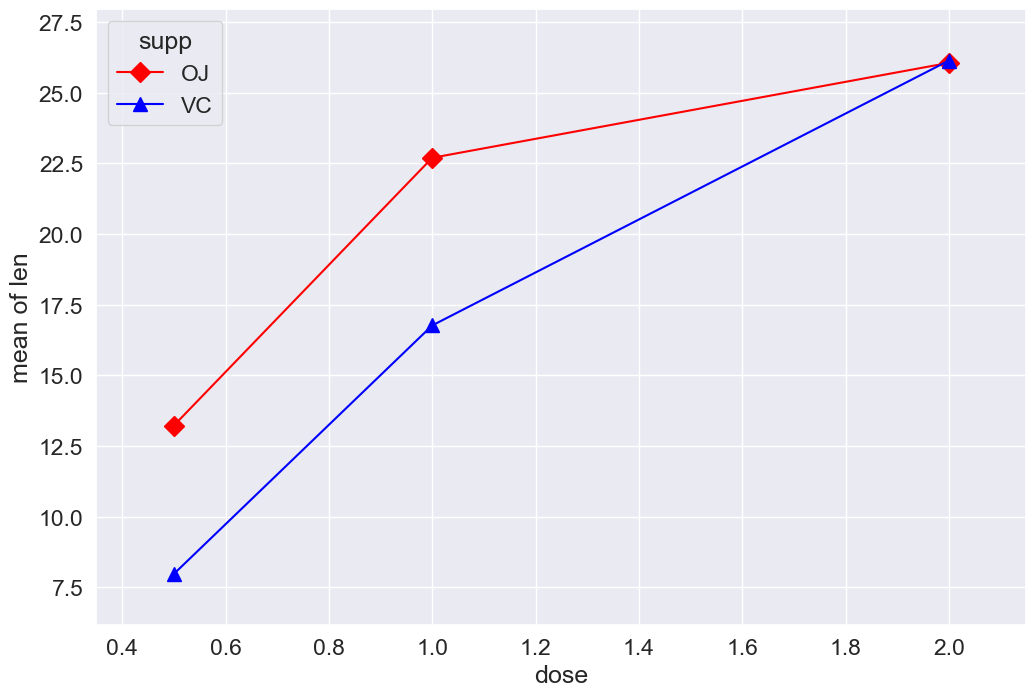

In [6]:
fig = interaction_plot(data.dose, 
                       data.supp, 
                       data.len,
                       colors=['red','blue'], markers=['D','^'], ms=10)
fig.set_figheight(8)
fig.set_figwidth(12)

## Two-way ANOVA

### How is the F‑statistic computed?

$$
F = \frac{SSE_R - SSE_F}{df_R - df_F} \cdot \frac{df_F}{SSE_F},
$$

where the subscript $F$ denotes the full model and the subscript $R$ denotes the reduced model.

### Three ways to define the full and reduced models

If we have two factors, we can write **seven** possible models:

$$1.\quad y_{ijk} = \mu + \alpha_j + \beta_k + (\alpha\beta)_{jk} + \epsilon_{ijk}$$

$$2.\quad y_{ijk} = \mu + \alpha_j + \beta_k + \epsilon_{ijk}$$

$$3.\quad y_{ijk} = \mu + \alpha_j + (\alpha\beta)_{jk} + \epsilon_{ijk}$$

$$4.\quad y_{ijk} = \mu + \beta_k + (\alpha\beta)_{jk} + \epsilon_{ijk}$$

$$5.\quad y_{ijk} = \mu + \alpha_j + \epsilon_{ijk}$$

$$6.\quad y_{ijk} = \mu + \beta_k + \epsilon_{ijk}$$

$$7.\quad y_{ijk} = \mu + \epsilon_{ijk}$$

In the literature, there are three common ways to choose $R$ and $F$, referred to as **Type I**, **Type II**, and **Type III** sums of squares (an informal but widely used terminology).

---

##### Type I

Also called the *sequential* model. It shows how much additional variation is explained when new variables are added **in order**.

* **Main effect of factor A:** F = 5, R = 7  
  SS(A)

* **Main effect of factor B:** F = 2, R = 5  
  SS(B | A)

* **Interaction effect:** F = 1, R = 2  
  SS(AB | A, B)

---

##### Type II

How much variation a variable explains when **all other main effects** are already included.

* **Main effect of factor A:** F = 2, R = 6  
  SS(A | B)

* **Main effect of factor B:** F = 2, R = 5  
  SS(B | A)

* **Interaction effect:** F = 1, R = 2  
  SS(AB | A, B)

---

##### Type III

How much variation a variable explains when **all other terms, including the interaction**, are already included.

* **Main effect of factor A:** F = 1, R = 4  
  SS(A | B, AB)

* **Main effect of factor B:** F = 1, R = 3  
  SS(B | A, AB)

* **Interaction effect:** F = 1, R = 2  
  SS(AB | A, B)

---

http://md.psych.bio.uni-goettingen.de/mv/unit/lm_cat/lm_cat_unbal_ss_explained.html

Let’s compute all constants and degrees of freedom.

In [7]:
N = len(data.len)
df_a = len(data.supp.unique()) - 1 # степени свободы по первому фактору
df_b = len(data.dose.unique()) - 1 # степени свободы по второму фактору
df_axb = df_a * df_b 
df_w = N - (len(data.supp.unique()) * len(data.dose.unique()))

The mean over all observations.

In [8]:
grand_mean = data['len'].mean()

The sum of errors between the group means and the overall mean.

In [9]:
ssq_a = sum([(data[data.supp==l].len.mean() - grand_mean)**2 for l in data.supp])

In [10]:
ssq_b = sum([(data[data.dose==l].len.mean() - grand_mean)**2 for l in data.dose])

The sum of errors between the overall mean and the individual observations.

In [11]:
ssq_t = sum((data.len - grand_mean)**2)

The sum of errors between the group means and the individual observations.

In [12]:
vc = data[data.supp == 'VC']
oj = data[data.supp == 'OJ']
vc_dose_means = [vc[vc.dose == d].len.mean() for d in vc.dose]
oj_dose_means = [oj[oj.dose == d].len.mean() for d in oj.dose]
ssq_w = sum((oj.len - oj_dose_means)**2) + sum((vc.len - vc_dose_means)**2)

![](https://www.marsja.se/wp-content/uploads/2016/03/two-way-anova-sum-of-squares.png)

In [13]:
ssq_axb = ssq_t - ssq_a - ssq_b - ssq_w

In [14]:
ms_a = ssq_a / df_a

In [15]:
ms_b = ssq_b / df_b

In [16]:
ms_axb = ssq_axb / df_axb

In [17]:
ms_w = ssq_w / df_w

### F‑statistics

In [18]:
f_a = ms_a / ms_w
f_b = ms_b / ms_w
f_axb = ms_axb / ms_w

### Let’s compute the p‑values

In [19]:
from scipy import stats

In [20]:
p_a = stats.f.sf(f_a, df_a, df_w)
p_b = stats.f.sf(f_b, df_b, df_w)
p_axb = stats.f.sf(f_axb, df_axb, df_w)

In [21]:
p_a, p_b, p_axb

(np.float64(0.0002311828097734238),
 np.float64(4.046291195992211e-18),
 np.float64(0.02186026896479111))

In [22]:
results = {
    'sum_sq': [ssq_a, ssq_b, ssq_axb, ssq_w],
    'df': [df_a, df_b, df_axb, df_w],
    'F': [f_a, f_b, f_axb, 'NaN'],
    'PR(>F)':[p_a, p_b, p_axb, 'NaN']
}

columns = ['sum_sq', 'df', 'F', 'PR(>F)']
 
aov_table1 = pd.DataFrame(results, 
                          columns=columns,
                          index=['supp', 'dose', 
                                 'supp:dose', 'Residual'])

In [23]:
aov_table1

,sum_sq,df,F,PR(>F)
supp,205.350000,1,15.571979,0.000231
dose,2426.434333,2,91.999965,0.0
supp:dose,108.319000,2,4.106991,0.02186
Residual,712.106000,54,NaN,NaN


### A few additional effect-size measures

1. $\eta^2$, something like $R^2$ in regression.

$$\eta^2 = SSbetween / SStotal = SSB / SST$$

Classic empirical interpretations of $\eta^2$:

  * .02 ~ small effect;
  * .13 ~ medium effect;
  * .26 ~ large effect.

2. $\omega^2$
  
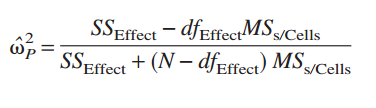

In [24]:
def eta_squared(aov):
    aov['eta_sq'] = 'NaN'
    aov['eta_sq'] = aov[:-1]['sum_sq'] / sum(aov['sum_sq'])
    return aov
 
def omega_squared(aov):
    mse = aov['sum_sq'][-1] / aov['df'][-1]
    aov['omega_sq'] = 'NaN'
    aov['omega_sq'] = (aov[:-1]['sum_sq'] - (aov[:-1]['df']*mse))/(sum(aov['sum_sq'])+mse)
    return aov


eta_squared(aov_table1)
omega_squared(aov_table1)
aov_table1

,sum_sq,df,F,PR(>F),eta_sq,omega_sq
supp,205.350000,1,15.571979,0.000231,0.059484,0.055452
dose,2426.434333,2,91.999965,0.0,0.702864,0.692579
supp:dose,108.319000,2,4.106991,0.02186,0.031377,0.023647
Residual,712.106000,54,NaN,NaN,NaN,NaN


### ANOVA from `statsmodels`

In [34]:
formula = 'len ~ C(supp) * C(dose)'
model = ols(formula, data).fit()
aov_table = anova_lm(model, typ=2)

eta_squared(aov_table)
omega_squared(aov_table)
aov_table

,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(supp),205.350000,1.0,15.571979,2.311828e-04,0.059484,0.055452
C(dose),2426.434333,2.0,91.999965,4.046291e-18,0.702864,0.692579
C(supp):C(dose),108.319000,2.0,4.106991,2.186027e-02,0.031377,0.023647
Residual,712.106000,54.0,NaN,NaN,NaN,NaN


### Q-Q график

It is very important to check that the leftovers are distributed normally.

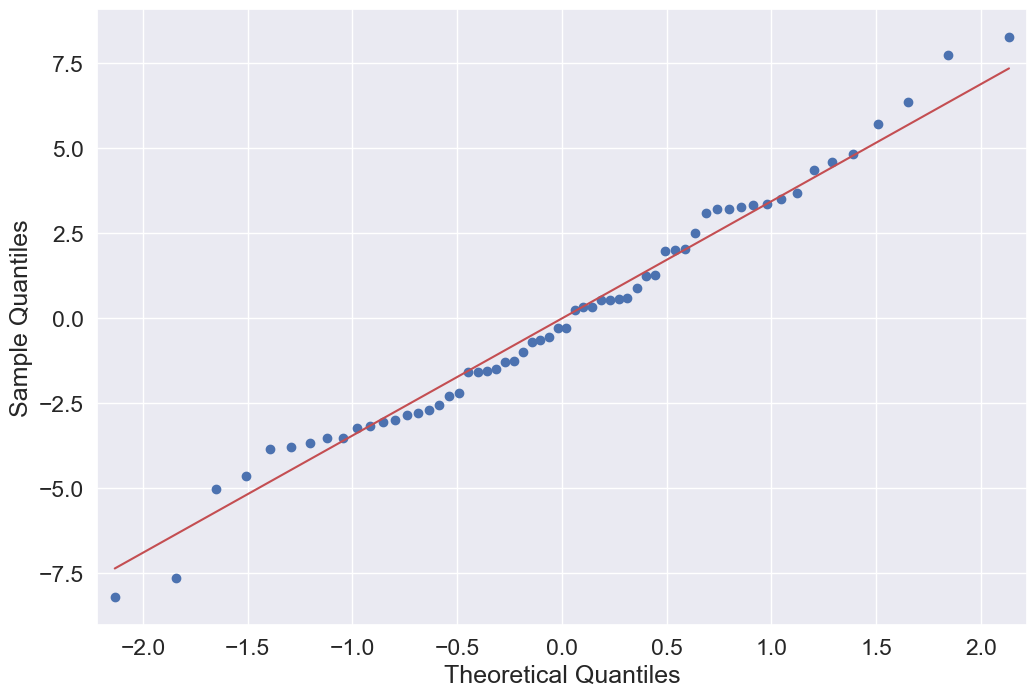

In [59]:
res = model.resid 
fig = sm.qqplot(res, line='s')
fig.set_figheight(8)
fig.set_figwidth(12)
plt.show()

##### Shapiro–Wilk test for checking normality


In [60]:
stats.shapiro(res)

ShapiroResult(statistic=np.float64(0.9849884303223122), pvalue=np.float64(0.6694241939351603))

# ANCOVA

In ANCOVA (Analysis of Covariance), we additionally include a regression on some covariate that may affect the variables we are interested in.

If we choose the covariate correctly, the residual variation should decrease.

However, it is also possible for the variance to increase.

In [16]:
lm = ols("MPG ~ C(Origin) * Weight", auto_mpg).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     261.6
Date:                Tue, 17 Feb 2026   Prob (F-statistic):          1.47e-121
Time:                        14:01:00   Log-Likelihood:                 157.02
No. Observations:                 392   AIC:                            -302.0
Df Residuals:                     386   BIC:                            -278.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -4.0905      0.046    -89.788      0.000      -4.180      -4.001
C(Origin)[T.2]            0.1448      0.111      1.310      0.191      -0.073       0.362
C(Origin)[T.3]           -0.1298      0.137     -0.945      0.345      -0.400       0.140
Weight                    0.0003   1.31e-05     25.739      0.000       0.000       0.000
C(Origin)[T.2]:Weight -6.941e-05   4.27e-05     -1.627      0.105      -0.000    1.45e-05
C(Origin)[T.3]:Weight  3.294e-05   5.92e-05      0.556      0.578   -8.34e-05       0.000
==============================================================================
Omnibus:                        4.668   Durbin-Watson:                   0.809
Prob(Omnibus):                  0.097   Jarque-Bera (JB):                5.361
Skew:                          -0.122   Prob(JB):                       0.0685
Kurtosis:                       3.518   Cond. No.                     5.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [17]:
lm.model.exog_names

['Intercept',
 'C(Origin)[T.2]',
 'C(Origin)[T.3]',
 'Weight',
 'C(Origin)[T.2]:Weight',
 'C(Origin)[T.3]:Weight']

In [18]:
anova_table = anova_lm(lm, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Origin),0.160266,2.0,3.002717,5.081324e-02
Weight,19.875463,1.0,744.767679,4.062089e-92
C(Origin):Weight,0.082622,2.0,1.547988,2.139927e-01
Residual,10.301103,386.0,NaN,NaN


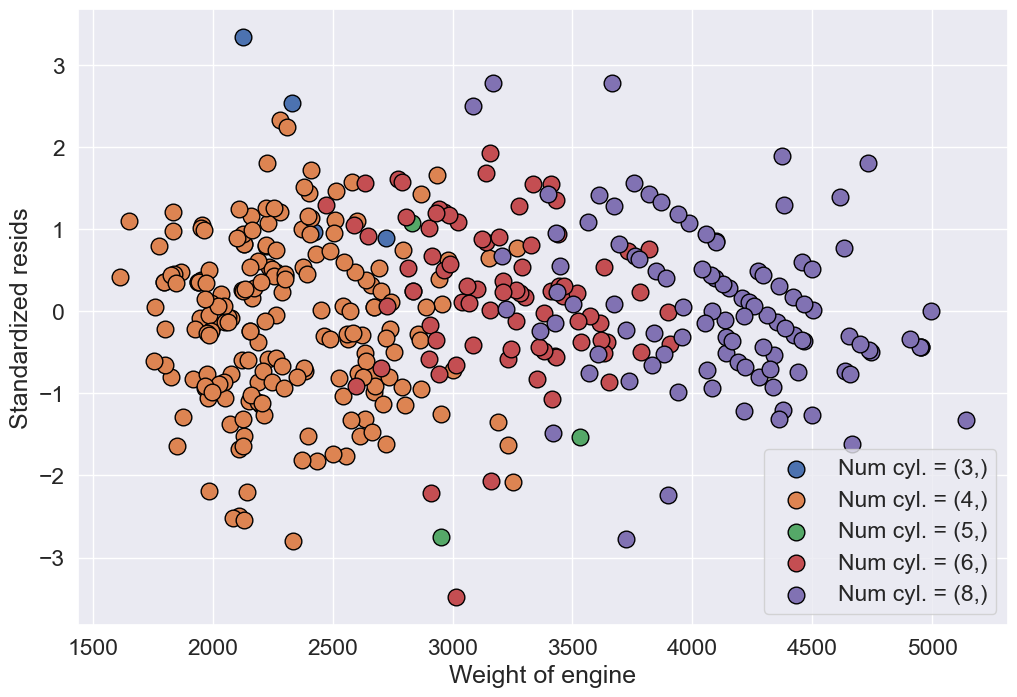

In [79]:
infl = lm.get_influence()
resid = infl.resid_studentized_internal
plt.figure(figsize=(12, 8))
for cylinder, group in auto_mpg.groupby(['Cylinders']):
    plt.scatter(auto_mpg.Weight[group.index], resid[group.index], s=144, 
                edgecolors='black', label='Num cyl. = {}'.format(cylinder))
plt.xlabel('Weight of engine');
plt.ylabel('Standardized resids');
plt.legend();

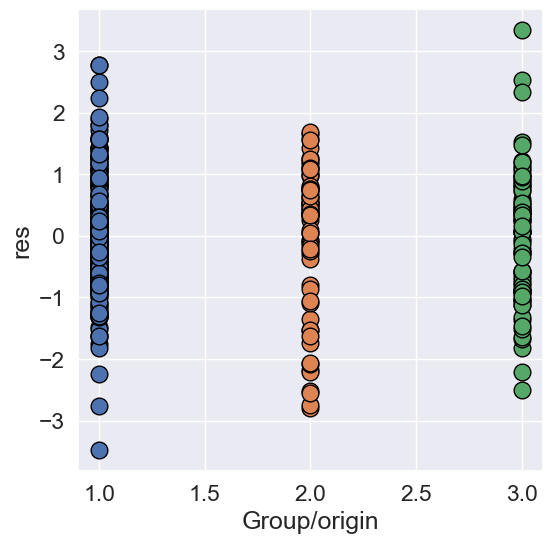

In [80]:
plt.figure(figsize=(6,6));
symbols = ['D', '^']
colors = ['r', 'g', 'blue']
for value, group in auto_mpg.groupby(['Origin']):
    x = [value] * len(group)
    plt.scatter(x, resid[group.index],
            s=144, edgecolors='black')
plt.xlabel('Group/origin');
plt.ylabel('res');

In [81]:
import IPython
for typ in ['I', 'II', 'III']:
    anova_table = anova_lm(lm, typ=typ)
    IPython.display.display(anova_table)

,df,sum_sq,mean_sq,F,PR(>F)
C(Origin),2.0,14.950773,7.475386,280.115536,6.980543e-76
Weight,1.0,19.875463,19.875463,744.767679,4.062089e-92
C(Origin):Weight,2.0,0.082622,0.041311,1.547988,2.139927e-01
Residual,386.0,10.301103,0.026687,NaN,NaN


,sum_sq,df,F,PR(>F)
C(Origin),0.160266,2.0,3.002717,5.081324e-02
Weight,19.875463,1.0,744.767679,4.062089e-92
C(Origin):Weight,0.082622,2.0,1.547988,2.139927e-01
Residual,10.301103,386.0,NaN,NaN


,sum_sq,df,F,PR(>F)
Intercept,215.146957,1.0,8061.925222,9.269477e-261
C(Origin),0.080165,2.0,1.501952,2.239936e-01
Weight,17.680040,1.0,662.501398,8.890714e-86
C(Origin):Weight,0.082622,2.0,1.547988,2.139927e-01
Residual,10.301103,386.0,NaN,NaN


## Testing ANCOVA assumptions

  * The relationship between x and y is linear;
  * The relationship between x and y is the same across groups (parallel slopes);
  * __x is independent of the group__ (because the conditions the subjects are in should be the same);
  * $y \mid x \sim \mathcal{N}(\mu + \alpha_j + \beta(x_{ij} - \bar{x}), \sigma^2)$ — homogeneity of variance.


#### 1. Linear dependence on the covariate for the outcome we want to predict

In [66]:
lm = ols("MPG ~ Weight", auto_mpg).fit()
anova_lm(lm)

,df,sum_sq,mean_sq,F,PR(>F)
Weight,1.0,34.665970,34.665970,1282.221169,2.392115e-125
Residual,390.0,10.543991,0.027036,NaN,NaN


The p‑value is equal to zero, as is the standard error, so the first assumption is satisfied.

#### 2. Parallel slopes

In [67]:
lm = ols("MPG ~ Weight * C(Origin)", auto_mpg).fit()
anova_lm(lm)

,df,sum_sq,mean_sq,F,PR(>F)
C(Origin),2.0,14.950773,7.475386,280.115536,6.980543e-76
Weight,1.0,19.875463,19.875463,744.767679,4.062089e-92
Weight:C(Origin),2.0,0.082622,0.041311,1.547988,2.139927e-01
Residual,386.0,10.301103,0.026687,NaN,NaN



We would expect to see a large p‑value here, which would indicate that the assumption of parallel slopes holds.

#### 3. Testing whether the covariate depends on the categorical factor

In [68]:
lm = ols("Weight ~ C(Origin)", auto_mpg).fit()
anova_lm(lm)

,df,sum_sq,mean_sq,F,PR(>F)
C(Origin),2.0,1.035338e+08,5.176691e+07,112.772038,2.353054e-39
Residual,389.0,1.785667e+08,4.590403e+05,NaN,NaN


There is a very strong dependence between weight and country of origin, which also violates the assumptions of ANcOVA.

#### 4. Testing the hypothesis of homogeneity of variance

https://en.wikipedia.org/wiki/Levene%27s_test

In [69]:
from scipy.stats import levene

In [70]:
levene?

Signature:
levene(
    *samples,
    center='median',
    proportiontocut=0.05,
    axis=0,
    nan_policy='propagate',
    keepdims=False,
)
Docstring:
Perform Levene test for equal variances.

The Levene test tests the null hypothesis that all input samples
are from populations with equal variances.  Levene's test is an
alternative to Bartlett's test `bartlett` in the case where
there are significant deviations from normality.

Parameters
----------
sample1, sample2, ... : array_like
    The sample data, possibly with different lengths. Only one-dimensional
    samples are accepted.
center : {'mean', 'median', 'trimmed'}, optional
    Which function of the data to use in the test.  The default
    is 'median'.
proportiontocut : float, optional
    When `center` is 'trimmed', this gives the proportion of data points
    to cut from each end. (See `scipy.stats.trim_mean`.)
    Default is 0.05.
axis : int or None, default: 0
    If an int, the axis of the input along which to compute th

In [71]:
levene(auto_mpg[auto_mpg.Origin==1].MPG,
       auto_mpg[auto_mpg.Origin==2].MPG,
       auto_mpg[auto_mpg.Origin==3].MPG)

LeveneResult(statistic=np.float64(11.084787110808314), pvalue=np.float64(2.080265441259958e-05))

The test for homogeneity of variance is passed :)

##### It is very important to test these assumptions before performing the analysis, because the validity of the conclusions directly depends on whether the assumptions hold.